# LCEL (LangChain Expression Language)
- LCEL은 LangChain에서 **체인(Chain)** 을 선언적으로 구성하기 위한 언어입니다.

### 주요 특징
- 선언적 구성: 작업의 순서와 흐름을 명시적으로 정의하여, 복잡한 로직을 간결하게 표현할 수 있습니다.
- 파이프 연산자(|) 지원: Unix의 파이프처럼, 함수의 출력을 다음 함수의 입력으로 전달하여 체인을 구성합니다.

> 코드 예제 
```ini
chain = prompt | llm | parser
```

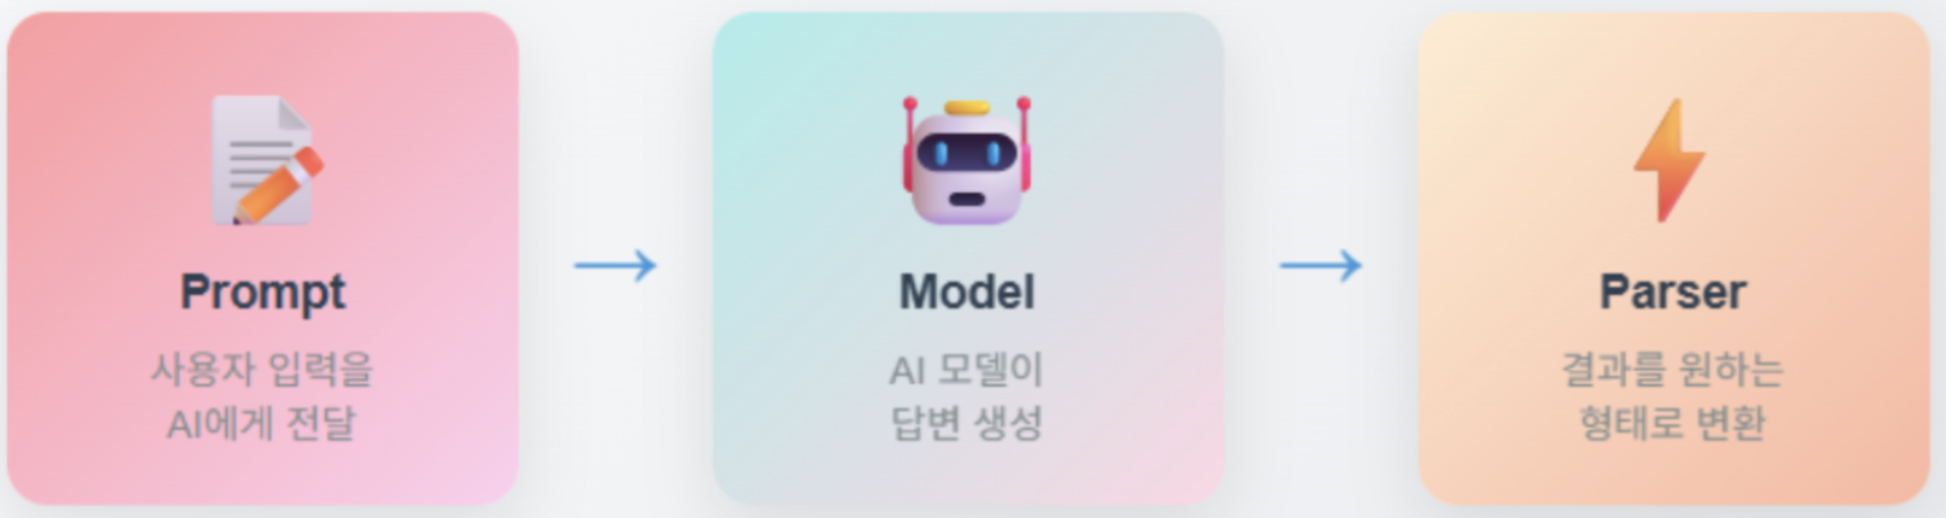

# 배치 처리 (Batch Processing)
- 여러 입력을 한 번에 처리할 수 있습니다.

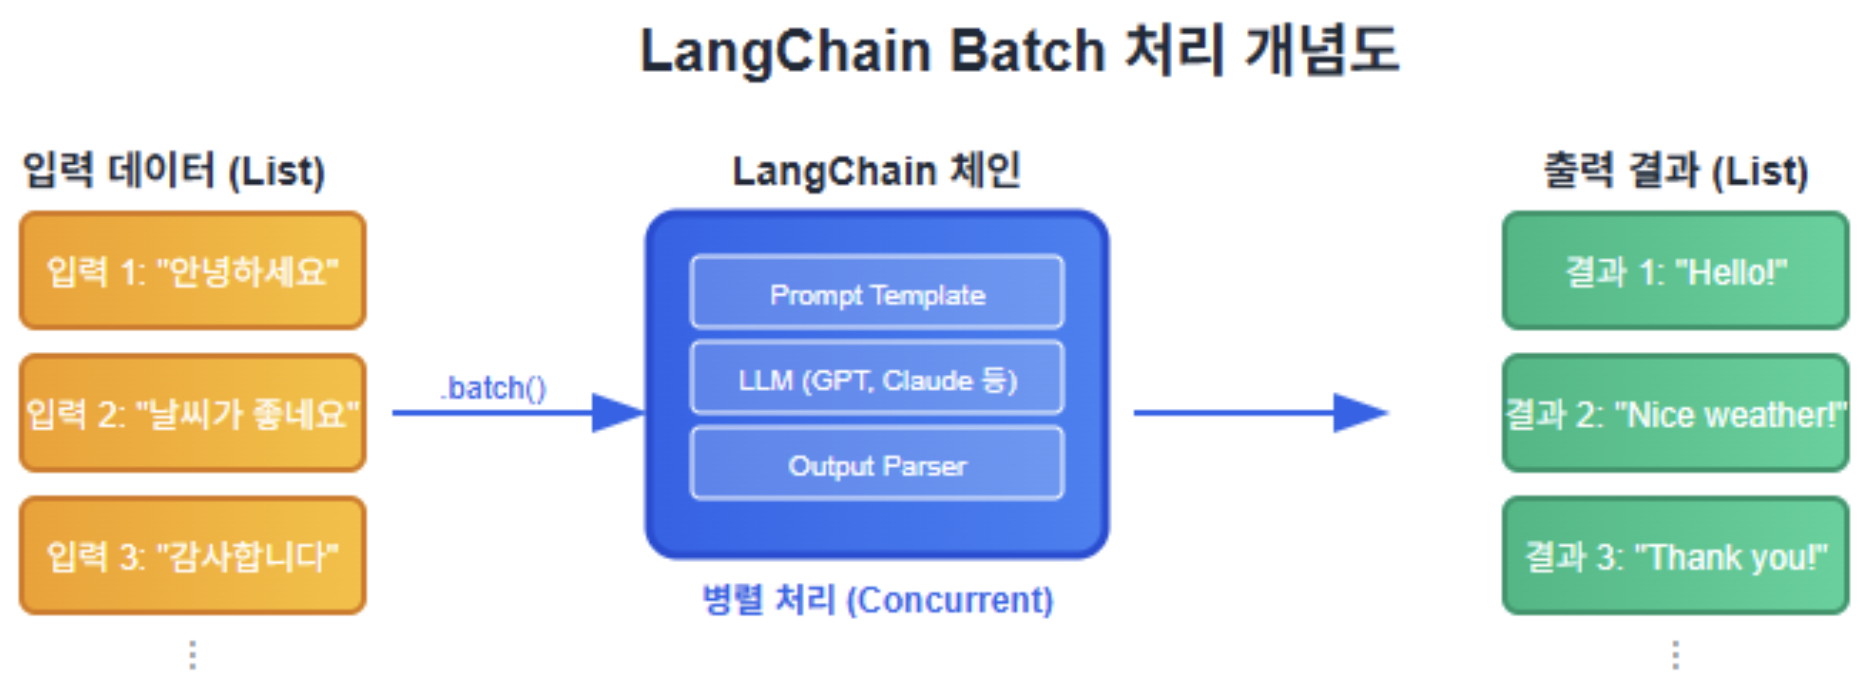

# Model

## [OpenAI API Key 발급](https://platform.openai.com/api-keys)

In [1]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

## ChatOpenAI

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

# Parser

In [3]:
from langchain_core.output_parsers import StrOutputParser

# OutputParser 설정
output_parser = StrOutputParser()

# PromptTemplate

In [4]:
from langchain_core.prompts import PromptTemplate

# 번역 체인 생성
translation_prompt = PromptTemplate.from_template(
    template="다음 텍스트를 {target_language}로 번역해주세요: {text}"
)



# Chain

In [5]:
translation_chain = translation_prompt | llm | output_parser

## 배치 처리 실행

In [6]:
# 배치 입력 데이터
batch_inputs = [
    {"text": "안녕하세요", "target_language": "영어"},
    {"text": "감사합니다", "target_language": "일본어"},
    {"text": "좋은 하루 되세요", "target_language": "중국어"},
    {"text": "만나서 반갑습니다", "target_language": "스페인어"}
]

In [7]:
# 배치 처리 실행
batch_results = translation_chain.batch(batch_inputs)

for i, (input_data, result) in enumerate(zip(batch_inputs, batch_results)):
    print(f"{i+1}. 원문: '{input_data['text']}' → {input_data['target_language']}: '{result}'")


1. 원문: '안녕하세요' → 영어: 'Hello.'
2. 원문: '감사합니다' → 일본어: '번역 결과: ありがとうございます。

참고: 더 격식 있게 말하고 싶으면 どうもありがとうございます 를 사용할 수 있습니다.'
3. 원문: '좋은 하루 되세요' → 중국어: '다음과 같이 중국어로 번역됩니다:
- 祝你有个美好的一天。

더 정중한 표현으로는 祝您有个美好的一天도 사용할 수 있습니다.'
4. 원문: '만나서 반갑습니다' → 스페인어: '스페인어로: Mucho gusto.

참고로 상황에 따라 다르게 쓸 수 있습니다.
- 격식 있는 표현: Encantado de conocerle. (화자가 남성일 때) / Encantada de conocerle. (화자가 여성일 때)
- 비격식 표현: Encantado de conocerte. (화자가 남성일 때) / Encantada de conocerte. (화자가 여성일 때)
- 가장 일반적이고 중립적인 표현: Mucho gusto.'
